In [1]:
import sys
sys.path.append("..")
%run "../moduli.py"

In [2]:
pesata = False

# Lettura

In [3]:
par_labels = [
    r"$f_{0,A_{\mathrm{fit}}}$",
    r"$f_{0,\Delta \Phi_{\mathrm{fit}}}$",  # da regressione

    r"$f_{0,A}$",
    r"$f_{0,\Delta \Phi}$",  # fatti da Zoya

    r"$f_{0,A_{\Delta f}}$",
    r"$f_{0,\Delta \Phi_{\Delta f}}$",  # correzione frequenza

    r"$f_0$"  # multimetro
]

par = [Misura(None, None) for _ in range(len(par_labels))]

Lettura Pickle ampiezza

In [4]:
a = Misura(None, None)
b = Misura(None, None)
c = Misura(None, None)
anal,offset = let.importa_pickle("ampiezza.pkl")
[[a.val, b.val, c.val], [a.s, b.s, c.s]] = anal
[x_off, y_off] = offset
del anal,offset

f = a.val / (2*np.pi)
sf = a.s / (2 * np.pi)
f0 = f - x_off

par[0] = Misura(f0, sf)
print(par[0])

73237.5997043973 ± 31.37825855579459


Lettura Pickle sfasamento

In [5]:
a = Misura(None, None)
b = Misura(None, None)
anal,offset = let.importa_pickle("sfasamento.pkl")
[[a.val, b.val], [a.s, b.s]] = anal
[x_off, y_off] = offset
del anal,offset

f = a.val / (2*np.pi)
sf = a.s / (2 * np.pi)
f0 = f - x_off

par[1] = Misura(f0, sf)
print(par[1])

72811.89172360052 ± 0.68544088580384


Misure di f0 nel Latex

In [6]:
par[2] = Misura(72.3e3,0.2e3)
par[3] = Misura(73.7e3,0.1e3)
par[4] = Misura(72.9e3,0.1e3)
par[5] = Misura(72.95e3,0.07e3)
par[6] = Misura(73.2e3,1.9e3)

Conversione

In [7]:
valori = np.array([m.val for m in par])
errori = np.array([m.s for m in par])

par = Misura(valori, errori)
del valori,errori

# Analisi

In [8]:
if pesata:
    media = an.media_p(par)
elif not pesata:
    media = an.media(par)

In [9]:
x = list(range(len(par_labels)))

In [10]:
residui = []

for i in range(len(par_labels)):
    res = (media.val - par.val[i])
    residui.append([x[i], res, par.s[i]])

residui = np.array(residui)
res = np.array([residui[:, 0], residui[:, 1], residui[:, 2]])

# Grafico

In [11]:
titolo = "Confronto stime frequenza di risonanza"

ylabel = "f_0"
yunit = "Hz"

file_output1 = "confronto_f0.pdf"

In [12]:
print(par)

73237.5997043973 ± 31.37825855579459
72811.89172360052 ± 0.68544088580384
72300.0 ± 200.0
73700.0 ± 100.0
72900.0 ± 100.0
72950.0 ± 70.0
73200.0 ± 1900.0



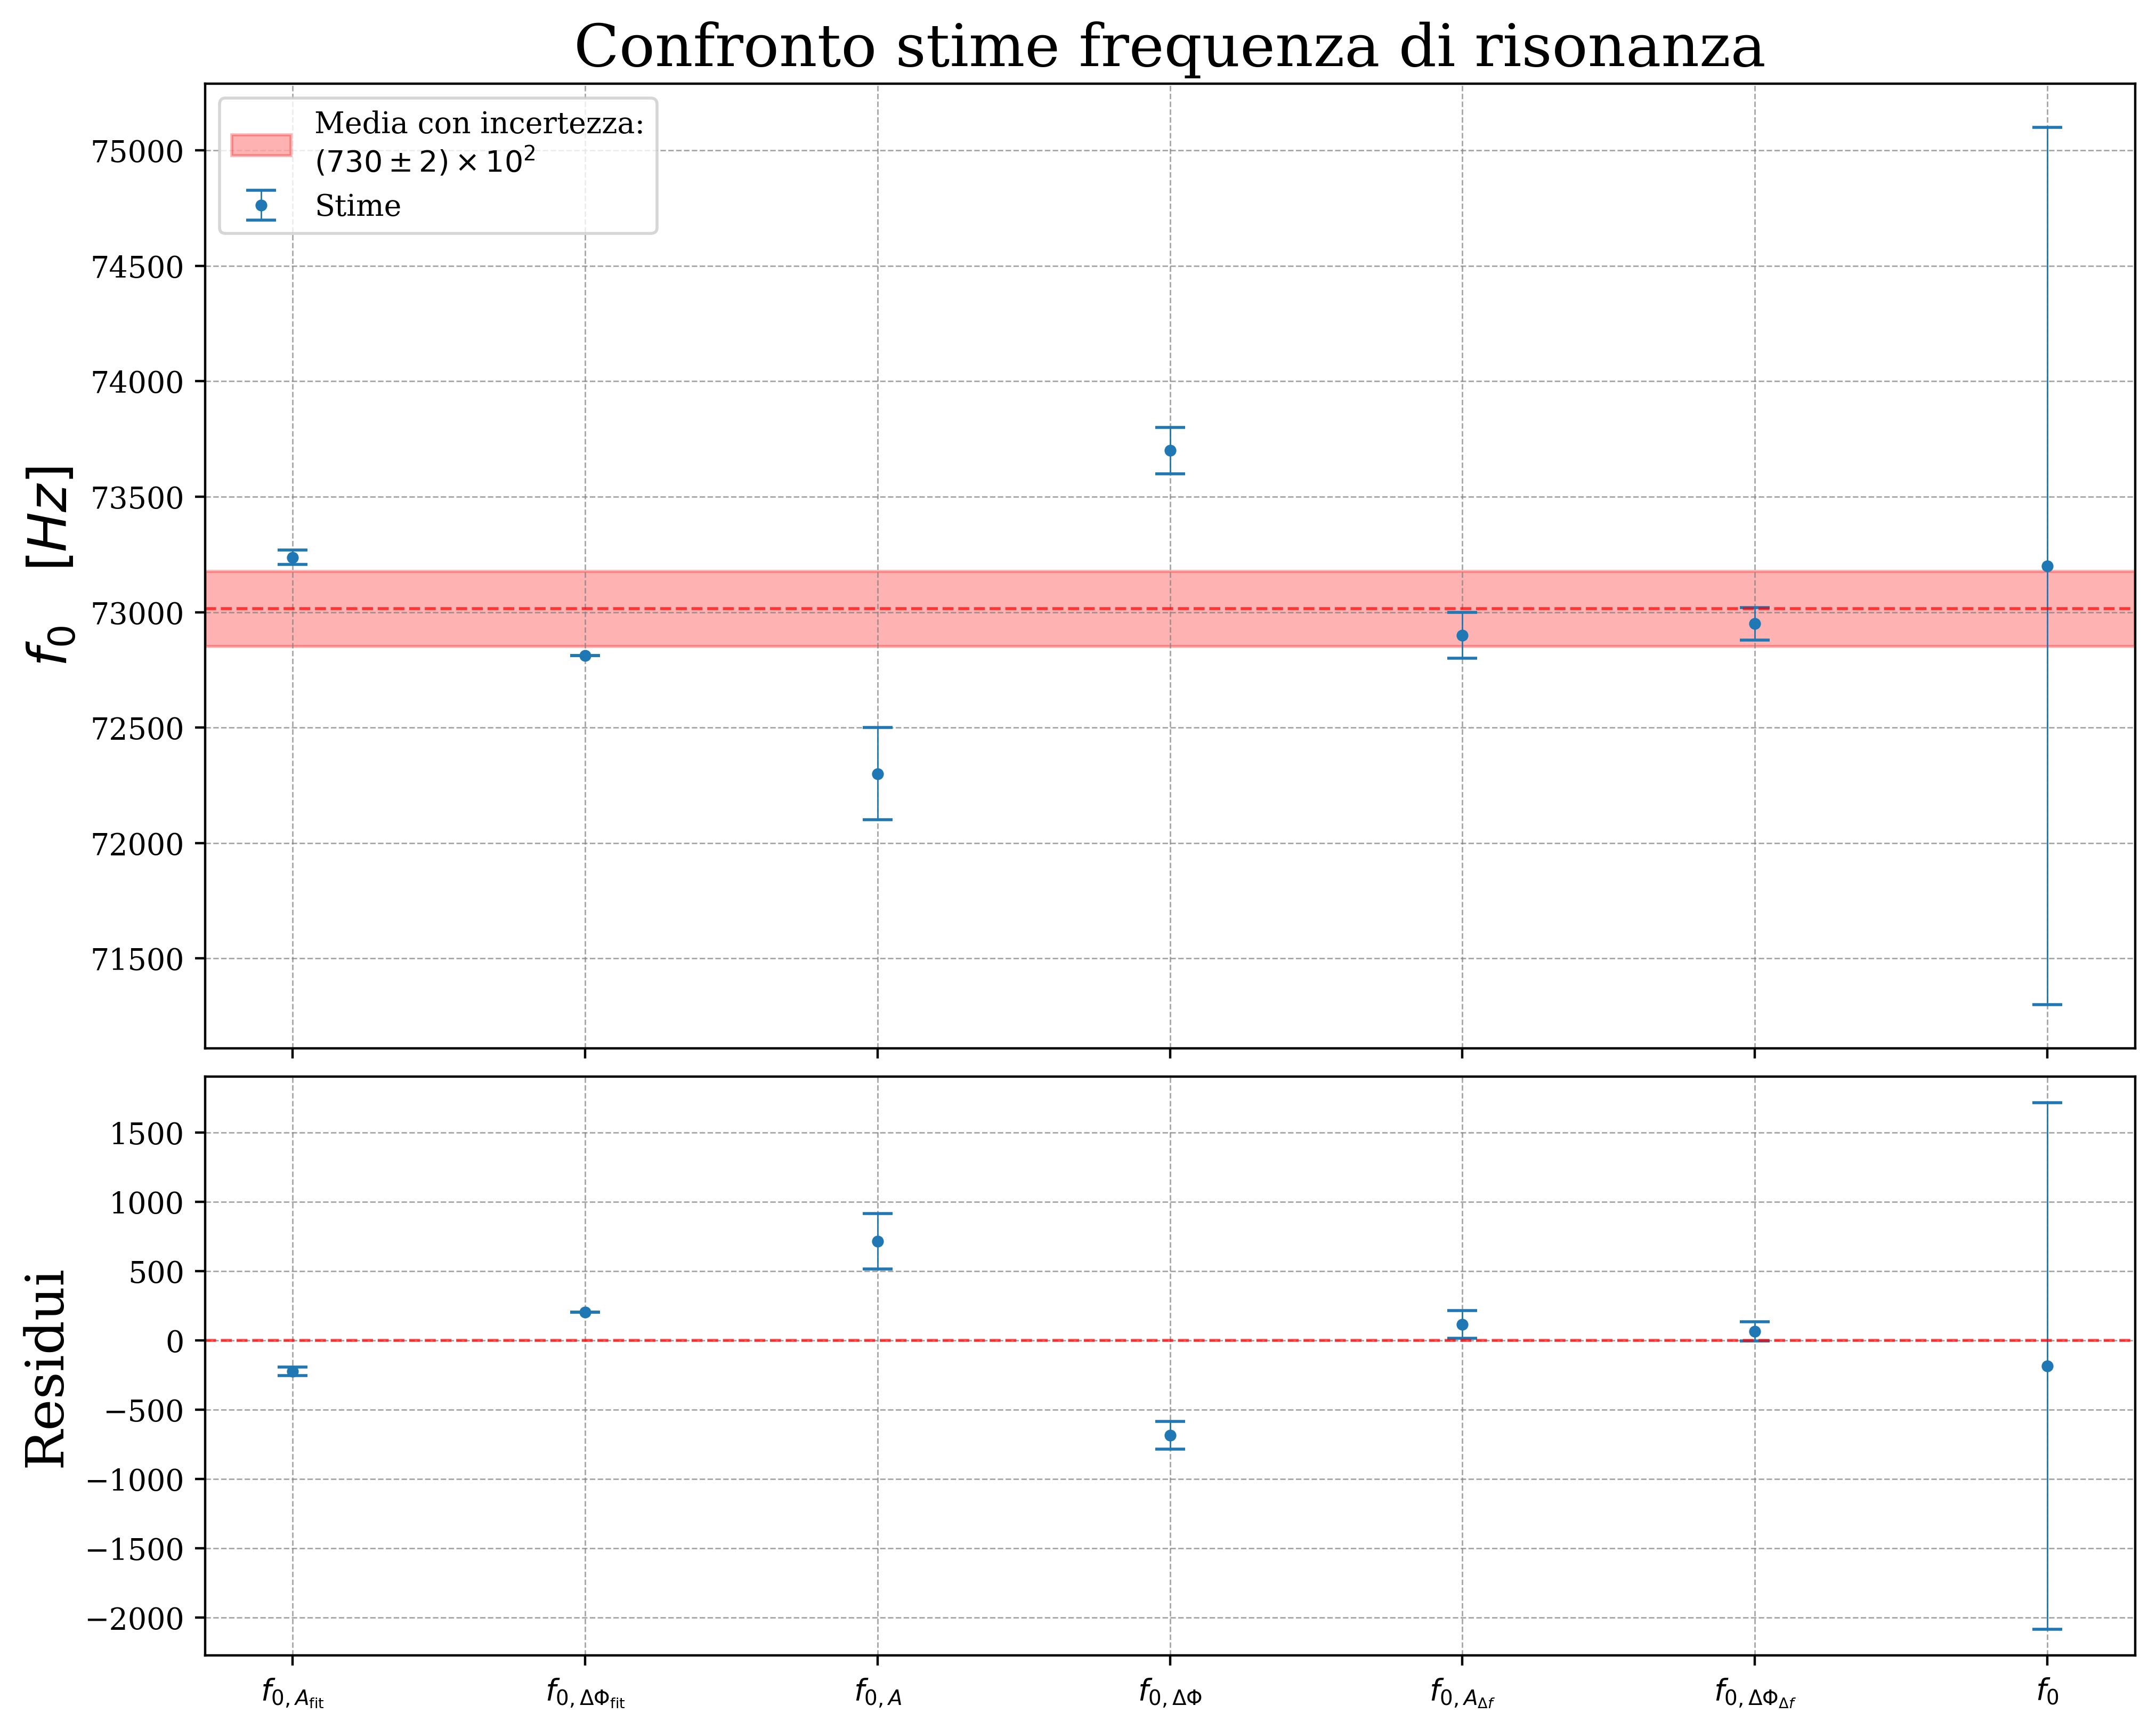

In [15]:
fig1, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(10, 8),
        gridspec_kw={'height_ratios': [5, 3]},
        constrained_layout=True,
        sharex=True
)
ax1.tick_params(axis='x', labelbottom=False)
gf.parametri_grafico(ax1, f"{titolo}", ylabel= rf"${ylabel}\quad [{yunit}]$")
gf.parametri_grafico(ax2, ylabel="Residui")

ax2.set_xticks(range(len(par_labels)))
ax2.set_xticklabels(par_labels)

# Dati
ax1.errorbar(
    x,
    par.val,
    yerr=par.s,
    label="Stime",
    **gf.errorbar_params,
    color = gf.colori[0]
)

# Media
ax1.axhline(
    media.val,
    **gf.line_params,
    color="red"
)
if pesata:
    label = "Media pesata con incertezza:\n"
elif not pesata:
    label = "Media con incertezza:\n"
ax1.axhspan(
    media.val - media.s,
    media.val + media.s,
    alpha=0.3,
    color="red",
    label=label + f"${gf.formatta_errore(media.val,media.s)}$"
)

ax1.legend(loc="upper left", bbox_to_anchor=(0,1), fontsize=10)

# Residui
ax2.errorbar(
    res[0],
    res[1],
    yerr=res[2],
    **gf.errorbar_params,
    color=gf.colori[0]
)

# Linea orizzontale
ax2.axhline(
    0,
    **gf.line_params,
    color="red"
)

let.salva_grafico(fig1, file_output1)

In [14]:
print(par)

73237.5997043973 ± 31.37825855579459
72811.89172360052 ± 0.68544088580384
72300.0 ± 200.0
73700.0 ± 100.0
72900.0 ± 100.0
72950.0 ± 70.0
73200.0 ± 1900.0

